In [17]:
#BiocManager::install("clusterProfiler", version = "3.18")
#BiocManager::install("pathview")
#BiocManager::install("enrichplot")
library(clusterProfiler)
library(enrichplot)
# we use ggplot2 to add x axis labels (ex: ridgeplot)
library(ggplot2)

In [18]:
organism = "org.Hs.eg.db"
#BiocManager::install("org.Hs.eg.db", version = "3.20")
library(organism, character.only = TRUE)

In [19]:
# Reading in data
df <- read.csv("/usr/users/papantonis1/aman/rnaseq_data/ranked_gene_list.txt", sep = "\t", header = TRUE)

# Remove version numbers from ENSEMBL IDs
df$ensembl_clean <- sub("\\..*", "", df$ensembl)

# Build named vector for gene list
original_gene_list <- df$log2FC
names(original_gene_list) <- df$ensembl_clean

# Filter NAs and sort
gene_list <- na.omit(original_gene_list)
gene_list <- sort(gene_list, decreasing = TRUE)

# Check it's working
head(gene_list)

ENSG00000228205 ENSG00000254211 ENSG00000285747 ENSG00000259571 ENSG00000132437 
       6.559015        5.900297        5.782576        5.777399        5.772329 
ENSG00000187288 
       5.497158

In [20]:
str(gene_list)

 Named num [1:49321] 6.56 5.9 5.78 5.78 5.77 ...
 - attr(*, "names")= chr [1:49321] "ENSG00000228205" "ENSG00000254211" "ENSG00000285747" "ENSG00000259571" ...


In [21]:
keytypes(org.Hs.eg.db)

[1] "ACCNUM"       "ALIAS"        "ENSEMBL"      "ENSEMBLPROT"  "ENSEMBLTRANS"
 [6] "ENTREZID"     "ENZYME"       "EVIDENCE"     "EVIDENCEALL"  "GENENAME"    
[11] "GENETYPE"     "GO"           "GOALL"        "IPI"          "MAP"         
[16] "OMIM"         "ONTOLOGY"     "ONTOLOGYALL"  "PATH"         "PFAM"        
[21] "PMID"         "PROSITE"      "REFSEQ"       "SYMBOL"       "UCSCKG"      
[26] "UNIPROT"

In [22]:
library(clusterProfiler)
library(org.Hs.eg.db)

id_map <- bitr(names(gene_list),
               fromType = "ENSEMBL",
               toType = "ENTREZID",
               OrgDb = org.Hs.eg.db)

# Keep only mappable genes
gene_list_mapped <- gene_list[names(gene_list) %in% id_map$ENSEMBL]
# Map ENSEMBL to ENTREZ with gene list
id_df <- id_map[match(names(gene_list), id_map$ENSEMBL), ]
df <- data.frame(ENTREZID = id_df$ENTREZID, log2FC = gene_list)

# Remove duplicated ENTREZ IDs
df <- df[!duplicated(df$ENTREZID), ]

# Final ranked vector for GSEA
gene_list_mapped <- df$log2FC
names(gene_list_mapped) <- df$ENTREZID

# Remove NA-named entries (unmapped ENSEMBL IDs)
gene_list_mapped <- gene_list_mapped[!is.na(names(gene_list_mapped))]


# Final sanity check
str(gene_list_mapped)
anyNA(names(gene_list_mapped))  # Should return FALSE

gene_list_mapped

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(names(gene_list), fromType = "ENSEMBL", toType = "ENTREZID", :
“47.63% of input gene IDs are fail to map...”


 Named num [1:25803] 6.56 5.9 5.78 5.77 5.5 ...
 - attr(*, "names")= chr [1:25803] "440991" "101928154" "414899" "1644" ...


[1] FALSE

440991     101928154        414899          1644         63924 
 6.559015e+00  5.900297e+00  5.777399e+00  5.772329e+00  5.497158e+00 
          117         57348        286754        165904     107986742 
 5.493458e+00  5.322548e+00  5.210183e+00  5.134285e+00  5.118526e+00 
    100422862     100113397     101928917     124901813         10891 
 5.101794e+00  5.029807e+00  4.929193e+00  4.928471e+00  4.909265e+00 
       125931          7503         11254        147381     100419436 
 4.909032e+00  4.900141e+00  4.890720e+00  4.890580e+00  4.881238e+00 
          269        654412         51442           717          4633 
 4.777107e+00  4.776138e+00  4.689370e+00  4.662175e+00  4.654263e+00 
         1825          1812        200844          2864     106479669 
 4.652114e+00  4.642921e+00  4.642869e+00  4.641009e+00  4.637224e+00 
       653156          3067         51267        388719         56000 
 4.637150e+00  4.635581e+00  4.632857e+00  4.631726e+00  4.631725e+00 
    108783646         11156        339403     100500845        124599 
 4.631586e+00  4.631522e+00  4.622006e+00  4.621411e+00  4.621352e+00 
    101928336          8808        204219     101926955     106479429 
 4.611290e+00  4.609874e+00  4.608628e+00  4.607986e+00  4.607978e+00 
         4661     127379695          6097          1806     100289656 
 4.607741e+00  4.500120e+00  4.487065e+00  4.482076e+00  4.472785e+00 
    110806272        284099     100418754     106481973        391099 
 4.463581e+00  4.344021e+00  4.344021e+00  4.343839e+00  4.339860e+00 
        79150        345041          6693     100507254        391135 
 4.338448e+00  4.329362e+00  4.329163e+00  4.328502e+00  4.327970e+00 
         9118          8832     105377031     100132076     107075279 
 4.326773e+00  4.325291e+00  4.324738e+00  4.315303e+00  4.315300e+00 
       285412        387590          6375     100506409         56146 
 4.315286e+00  4.315281e+00  4.315111e+00  4.315044e+00  4.315020e+00 
       256051          5334          3026        729085         84101 
 4.314897e+00  4.307936e+00  4.305443e+00  4.304971e+00  4.304046e+00 
         3853     106479434         27098           108        285596 
 4.302863e+00  4.302550e+00  4.302211e+00  4.301776e+00  4.301450e+00 
       115361     105378934        645687         84699         25984 
 4.301051e+00  4.301012e+00  4.301012e+00  4.301012e+00  4.301005e+00 
    100505591     106480409          6035          6010         26526 
 4.288908e+00  4.288619e+00  4.287447e+00  4.287218e+00  4.287163e+00 
        84217     107075134          3036     124900224         84871 
 4.286947e+00  4.286130e+00  4.286116e+00  4.139219e+00  4.118628e+00 
    100132891         90249     106479742     105376121        164781 
 4.110435e+00  4.110182e+00  4.110182e+00  4.109396e+00  4.099537e+00 
       386597     100288801          4311          2554         51214 
 3.928763e+00  3.928763e+00  3.928763e+00  3.928763e+00  3.928763e+00 
    124902897     106480950     100420325     106480148     100129774 
 3.928763e+00  3.928763e+00  3.928763e+00  3.928690e+00  3.928670e+00 
        93650     100418720     101929268        729083         29930 
 3.928205e+00  3.928027e+00  3.927735e+00  3.927442e+00  3.926986e+00 
       283659        645939     101928264         81035        123920 
 3.926970e+00  3.926750e+00  3.924787e+00  3.924459e+00  3.923746e+00 
         8600     100126270        254910        646127          9201 
 3.922738e+00  3.921069e+00  3.909805e+00  3.909805e+00  3.909691e+00 
         2016        644246        644548          2170     100616284 
 3.909647e+00  3.909647e+00  3.909637e+00  3.909559e+00  3.909489e+00 
         3363         89832          5789     100271553        150291 
 3.909321e+00  3.909321e+00  3.909185e+00  3.909175e+00  3.909125e+00 
        81244        653140         84684        343702        400541 
 3.908417e+00  3.906117e+00  3.905591e+00  3.905386e+00  3.901769e+00 
        54570         10021    

In [23]:
# Strip version from Ensembl IDs
ens_ids <- gsub("\\..*", "", names(gene_list))

# Map Ensembl to Gene Symbols
library(clusterProfiler)
library(org.Hs.eg.db)
symbol_map <- bitr(ens_ids, fromType = "ENSEMBL", toType = "SYMBOL", OrgDb = org.Hs.eg.db)

# Create a modular data frame with log2FC and gene symbols
gene_logfc_df <- data.frame(ENSEMBL = ens_ids, log2FC = gene_list)
gene_logfc_df <- merge(gene_logfc_df, symbol_map, by = "ENSEMBL")

# Final table: SYMBOL, ENSEMBL, log2FC
head(gene_logfc_df)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(ens_ids, fromType = "ENSEMBL", toType = "SYMBOL", OrgDb = org.Hs.eg.db):
“47.63% of input gene IDs are fail to map...”


,ENSEMBL,log2FC,SYMBOL
,<chr>,<dbl>,<chr>
1,ENSG00000000003,-0.008827647,TSPAN6
2,ENSG00000000419,-0.074333786,DPM1
3,ENSG00000000457,-0.027713822,SCYL3
4,ENSG00000000460,-0.057306352,FIRRM
5,ENSG00000000938,2.329072136,FGR
6,ENSG00000000971,-2.422586914,CFH


In [24]:
gsea_result <- gseGO(geneList = gene_list_mapped,
                     ont = "ALL",
                     keyType = "ENTREZID",
                     OrgDb = org.Hs.eg.db,
                     nPerm = 10000,
                     minGSSize = 3,
                     maxGSSize = 800,
                     pvalueCutoff = 0.1,
                     pAdjustMethod = "none",
                     verbose = TRUE)


preparing geneSet collections...

GSEA analysis...

Warning message in .GSEA(geneList = geneList, exponent = exponent, minGSSize = minGSSize, :
“We do not recommend using nPerm parameter incurrent and future releases”
Warning message in fgsea(pathways = geneSets, stats = geneList, nperm = nPerm, minSize = minGSSize, :
“You are trying to run fgseaSimple. It is recommended to use fgseaMultilevel. To run fgseaMultilevel, you need to remove the nperm argument in the fgsea function call.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (5.26% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



In [25]:
gsea_result

#
# Gene Set Enrichment Analysis
#
#...@organism 	 Homo sapiens 
#...@setType 	 GOALL 
#...@keytype 	 ENTREZID 
#...@geneList 	 Named num [1:25803] 6.56 5.9 5.78 5.77 5.5 ...
 - attr(*, "names")= chr [1:25803] "440991" "101928154" "414899" "1644" ...
#...nPerm 	 10000 
#...pvalues adjusted by 'none' with cutoff <0.1 
#...1106 enriched terms found
'data.frame':	1106 obs. of  12 variables:
 $ ONTOLOGY       : chr  "CC" "CC" "BP" "CC" ...
 $ ID             : chr  "GO:0005925" "GO:0030055" "GO:0031589" "GO:0030139" ...
 $ Description    : chr  "focal adhesion" "cell-substrate junction" "cell-substrate adhesion" "endocytic vesicle" ...
 $ setSize        : int  413 423 336 325 78 4 4 63 3 3 ...
 $ enrichmentScore: num  0.466 0.469 0.469 0.466 0.637 ...
 $ NES            : num  1.5 1.51 1.49 1.47 1.72 ...
 $ pvalue         : num  0.000186 0.000186 0.000188 0.000188 0.000192 ...
 $ p.adjust       : num  0.000186 0.000186 0.000188 0.000188 0.000192 ...
 $ qvalue         : num  0.57 0.57 0.57 0.

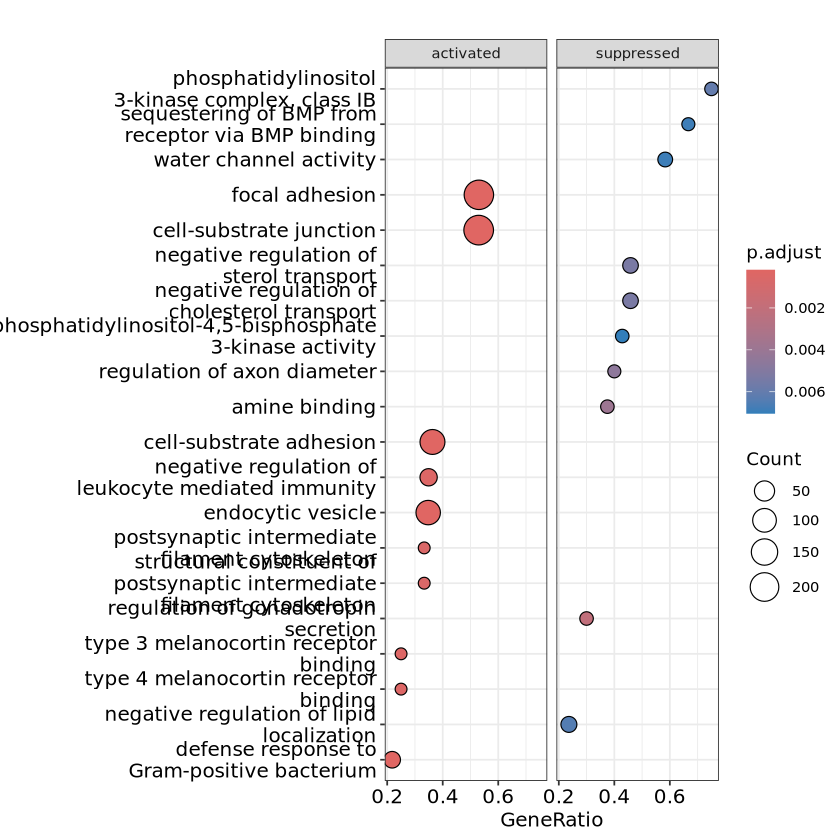

In [26]:
require(DOSE)
dotplot(gsea_result, showCategory=10, split=".sign") + facet_grid(.~.sign)

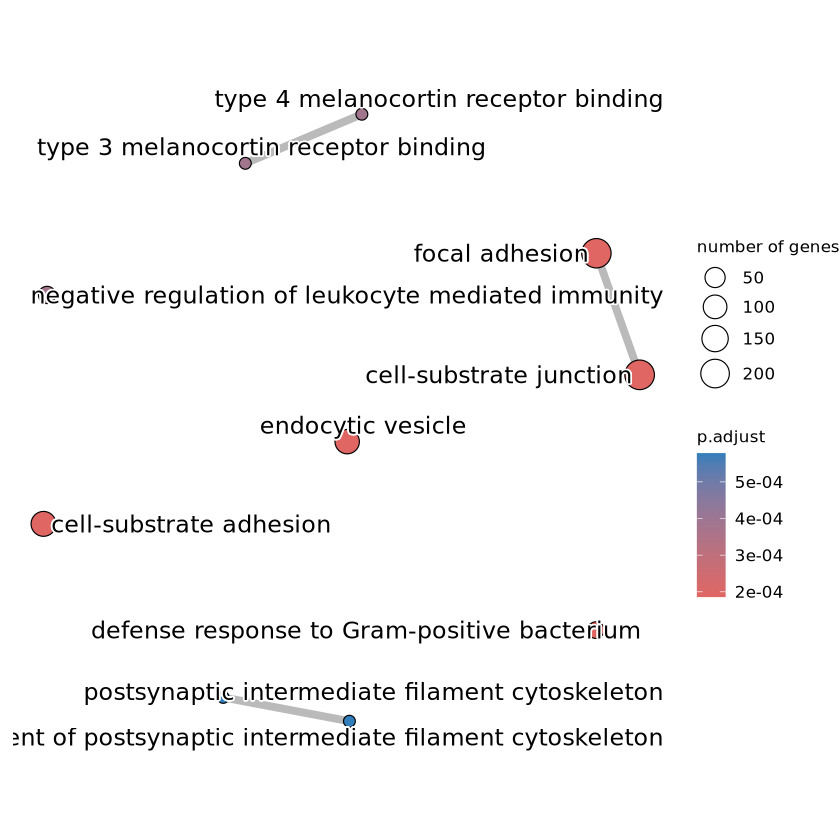

In [27]:
gsea_result <- pairwise_termsim(gsea_result)
emapplot(gsea_result, showCategory = 10)

Warning message in cnetplot.enrichResult(x, ...):
“Use 'color.params = list(foldChange = your_value)' instead of 'foldChange'.
 The foldChange parameter will be removed in the next version.”


Warning message:
“ggrepel: 129 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


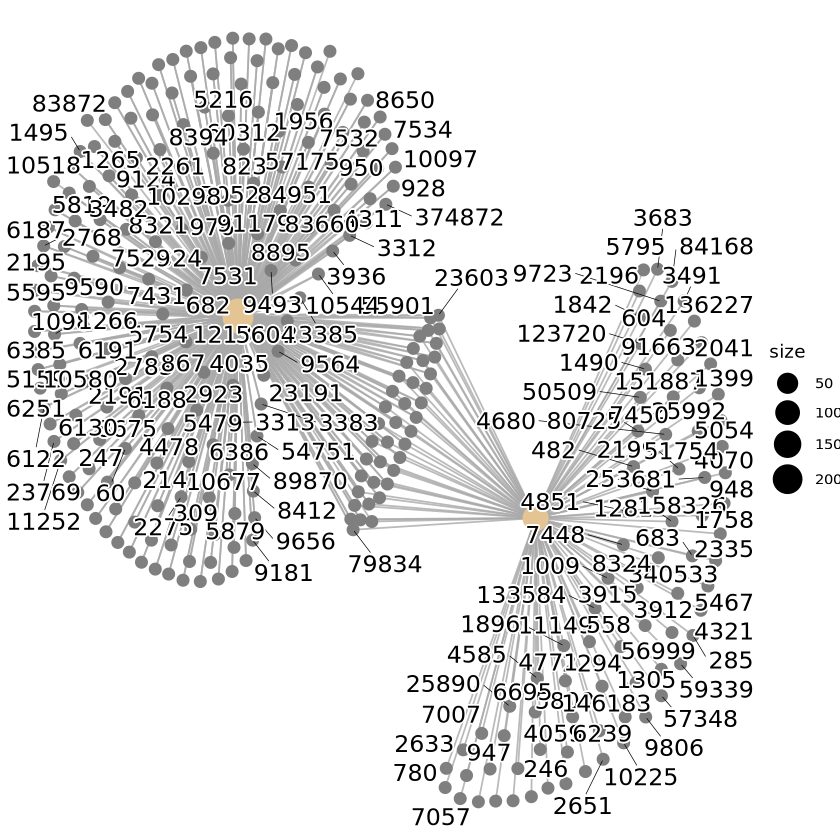

In [28]:
# categorySize can be either 'pvalue' or 'geneNum'
cnetplot(gsea_result, categorySize="pvalue", foldChange=gene_list, showCategory = 3)

Picking joint bandwidth of 0.242



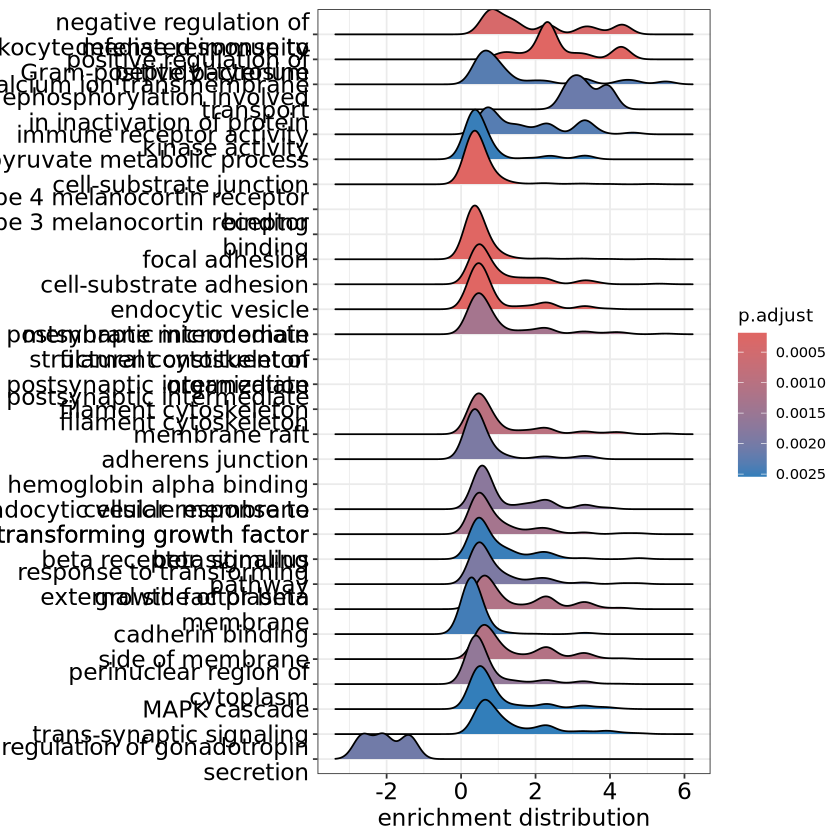

In [29]:
ridgeplot(gsea_result) + labs(x = "enrichment distribution")

In [30]:
#gsea_result@result$Description <- stringr::str_wrap(gsea_result@result$Description, width = 30)

Picking joint bandwidth of 0.237



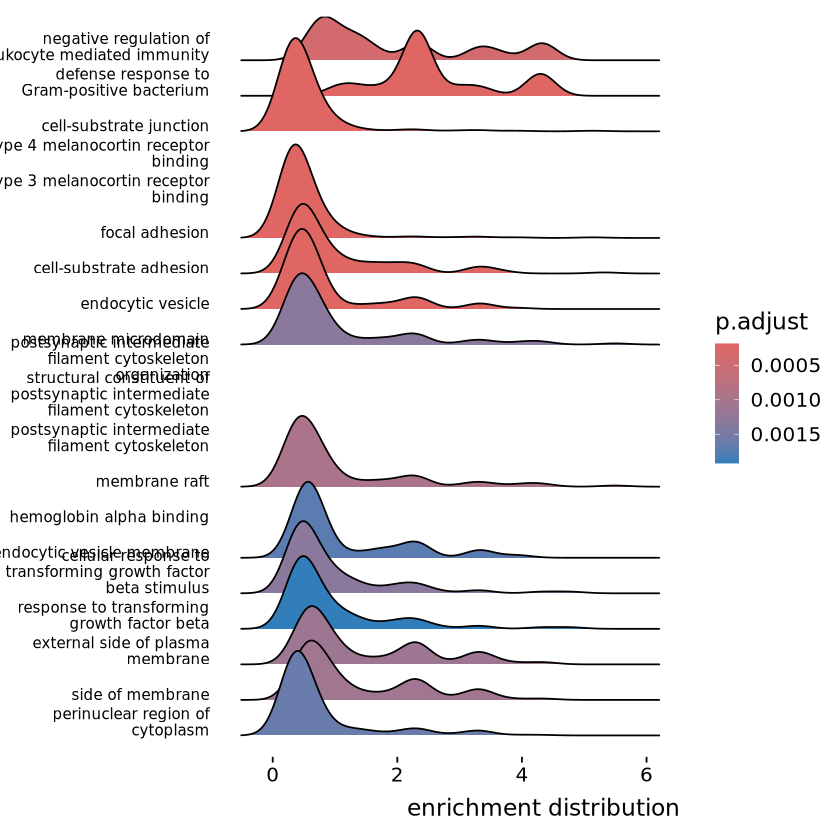

In [31]:
library(ggridges)

ridgeplot(gsea_result, showCategory = 20, fill = "p.adjust") +
  theme_ridges(grid = FALSE) +
  labs(x = "enrichment distribution") +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(10, 10, 10, 10),
    panel.spacing = unit(1.4, "lines")
  )


In [32]:
gsea_result$Description

[1] "focal adhesion"                                                                                                                                  
   [2] "cell-substrate junction"                                                                                                                         
   [3] "cell-substrate adhesion"                                                                                                                         
   [4] "endocytic vesicle"                                                                                                                               
   [5] "defense response to Gram-positive bacterium"                                                                                                     
   [6] "type 3 melanocortin receptor binding"                                                                                                            
   [7] "type 4 melanocortin receptor binding"                                                                                                            
   [8] "negative regulation of leukocyte mediated immunity"                                                                                              
   [9] "postsynaptic intermediate filament cytoskeleton"                                                                                                 
  [10] "structural constituent of postsynaptic intermediate filament cytoskeleton"                                                                       
  [11] "postsynaptic intermediate filament cytoskeleton organization"                                                                                    
  [12] "membrane raft"                                                                                                                                   
  [13] "side of membrane"                                                                                                                                
  [14] "external side of plasma membrane"                                                                                                                
  [15] "membrane microdomain"                                                                                                                            
  [16] "cellular response to transforming growth factor beta stimulus"                                                                                   
  [17] "perinuclear region of cytoplasm"                                                                                                                 
  [18] "endocytic vesicle membrane"                                                                                                                      
  [19] "response to transforming growth factor beta"                                                                                                     
  [20] "hemoglobin alpha binding"                                                                                                                        
  [21] "adherens junction"                                                                                                                               
  [22] "regulation of gonadotropin secretion"                                                                                                            
  [23] "peptidyl-tyrosine dephosphorylation involved in inactivation of protein kinase activity"                                                         
  [24] "positive regulation of calcium ion transmembrane transport"                                                                                      
  [25] "immune receptor activity"                                                                                                                        
  [26] "cadherin binding"                                                                                                                                

In [70]:
c2 <- read.gmt("/usr/users/papantonis1/aman/rnaseq_data/msigdb.v2025.1.Hs.entrez.gmt") # MSigDB
gseaGO2 <- GSEA(gene_list, 
             TERM2GENE=c2, 
             minGSSize = 10,
             nPerm = 1000, 
             pvalueCutoff = 1,
             verbose=FALSE)

--> Expected input gene ID: 50846,64400,6660,57403,55190,26059



ERROR: Error in check_gene_id(geneList, geneSets): --> No gene can be mapped....


In [65]:
head(names(gene_list_mapped)) # entrez

[1] "440991"    "101928154" "414899"    "1644"      "63924"     "117"

In [66]:
gseaGO2

#
# Gene Set Enrichment Analysis
#
#...@organism 	 UNKNOWN 
#...@setType 	 UNKNOWN 
#...@geneList 	 Named num [1:25803] 6.56 5.9 5.78 5.77 5.5 ...
 - attr(*, "names")= chr [1:25803] "440991" "101928154" "414899" "1644" ...
#...nPerm 	 1000 
#...pvalues adjusted by 'BH' with cutoff <1 
#...27665 enriched terms found
'data.frame':	27665 obs. of  11 variables:
 $ ID             : chr  "MIR4693_3P" "FLORIO_HUMAN_NEOCORTEX" "BRIDEAU_IMPRINTED_GENES" "chr1q44" ...
 $ Description    : chr  "MIR4693_3P" "FLORIO_HUMAN_NEOCORTEX" "BRIDEAU_IMPRINTED_GENES" "chr1q44" ...
 $ setSize        : int  57 31 52 58 13 69 24 44 153 50 ...
 $ enrichmentScore: num  0.702 -0.786 0.707 -0.688 0.898 ...
 $ NES            : num  1.84 -1.83 1.81 -1.79 1.72 ...
 $ pvalue         : num  0.00193 0.00197 0.00201 0.00206 0.00192 ...
 $ p.adjust       : num  0.903 0.903 0.903 0.903 0.903 ...
 $ qvalue         : num  0.903 0.903 0.903 0.903 0.903 ...
 $ rank           : num  4330 960 3966 3003 27 ...
 $ leading_edge   :

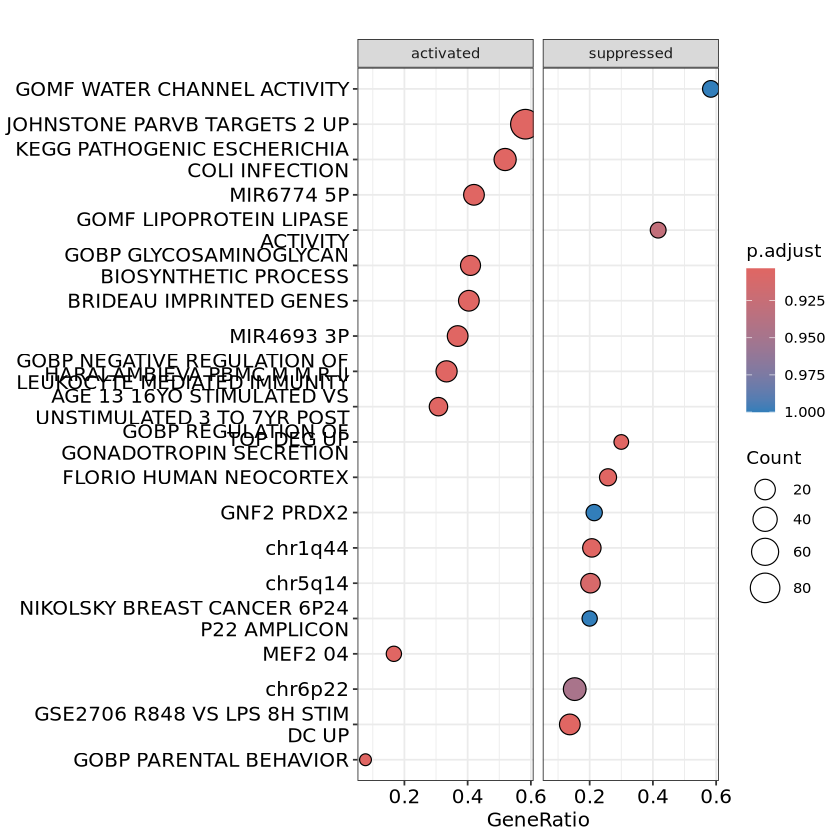

In [67]:
require(DOSE)
dotplot(gseaGO2, showCategory=10, split=".sign") + facet_grid(.~.sign)

In [68]:
unique_gmt_genes <- unique(unlist(c2$gene))
sum(names(gene_list_mapped) %in% unique_gmt_genes)
# Should be a nonzero value (ideally thousands).

[1] 25093

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-6.18892 -0.17080  0.00000  0.02799  0.25306  6.55901 

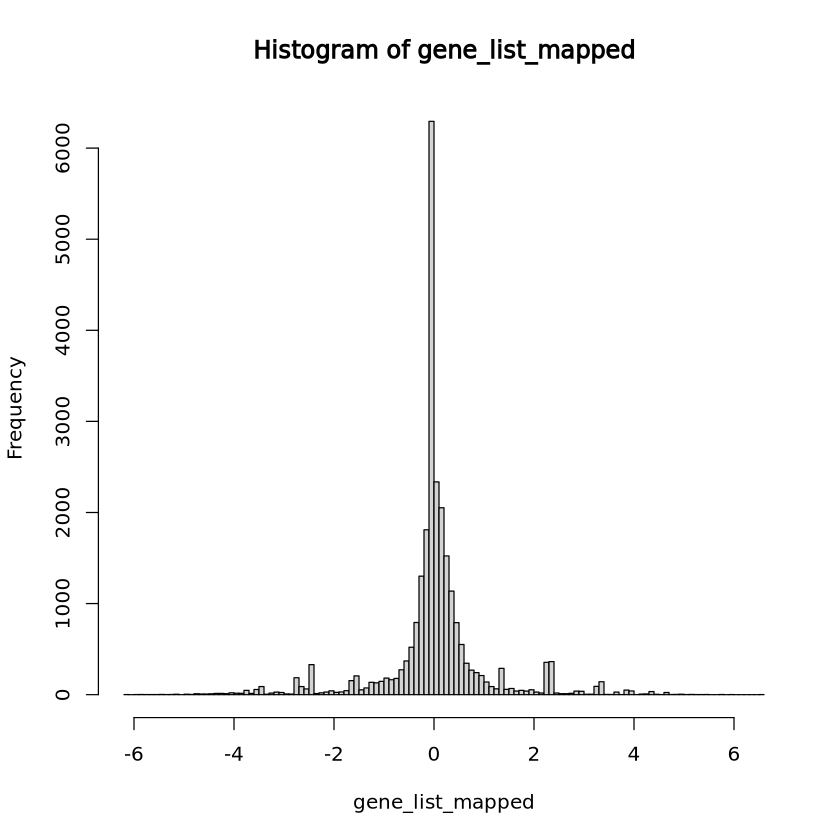

In [69]:
hist(gene_list_mapped, breaks=100)
summary(gene_list_mapped)

#### Connecting back to loops (loop anchors)